<a href="https://colab.research.google.com/github/oliviaberset/2026_solute_transport/blob/main/E1_solute_data_processing_Plynlimon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 1: Processing solute data

Goal: get familiar with typical operations that are useful for data visualization

## The data

We will use the [Plynlimon research catchment hydrochemistry](https://doi.org/10.5285/44095e17-43b0-45d4-a781-aab4f72da025) published by Neal, Kirchner, and Reynolds (2013) and previously described in Neal et al. ([2011](https://doi.org/10.1002/hyp.8191)). The data are part of a large data collection from the [Plynlimon experimental watersheds](https://www.ceh.ac.uk/our-science/monitoring-sites/plynlimon-research-catchments) (UK), which have been studied for years and have led to tens of scientific papers.

The hydrochemistry data files include:

- **supporting-documents**, with several metadata files describing the sites, the field and analytical methods, and with a full description of the measured variables.

- **data/PlynlimonResearchCatchmentHydrochemistryData.csv**, which is a data table with the measured hydrochemistry at the different sites collected approximately at weekly frequency. The data table has 15661 rows and 143 columns. All column names with "RDA" include the raw data version of the measurements.

In [10]:
# Load the main packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

### Data import

In [13]:
# Import the data into a Pandas DataFrame
data_path = os.path.join(  # indicate where the data is to be found
    "weekly_hydrochem",
    "data",
    "PlynlimonResearchCatchmentHydrochemistryData.csv"
    )
df = pd.read_csv(data_path)

# Since the variable "date_time" is not automatically recognised as
# date, let's force it to be a pd datetime object
df["date_time"] = pd.to_datetime(df["date_time"])

### Exercise #1

We want to explore linear relationships across a selection of measurements. We want to do this separately for the Upper and Lower Hafren sites.

You are free to select your measurements of interest. Make sure you include at least: "Cl mg/l", "Na mg/l", "Si mg/l", "log_flow"   

To display variables in pairs it is very convenient to use the `sns.pairplot` ([documentation](https://seaborn.pydata.org/generated/seaborn.pairplot.html)).

         SITE NAME           date_time  Cl mg/l  Na mg/l  Si mg/l  log_flow
3770  Lower Hafren 1995-01-03 10:25:00      6.5     3.98     1.85 -0.774691
3771  Lower Hafren 1995-01-10 09:30:00      7.5     4.49     1.40 -0.368556
3772  Lower Hafren 1995-01-17 09:18:00      6.9     4.18     1.70 -0.546682
3773  Lower Hafren 1995-01-24 09:30:00      8.7     4.54     1.45 -0.473661
3774  Lower Hafren 1995-01-31 10:00:00      7.3     3.85     1.30 -0.239577


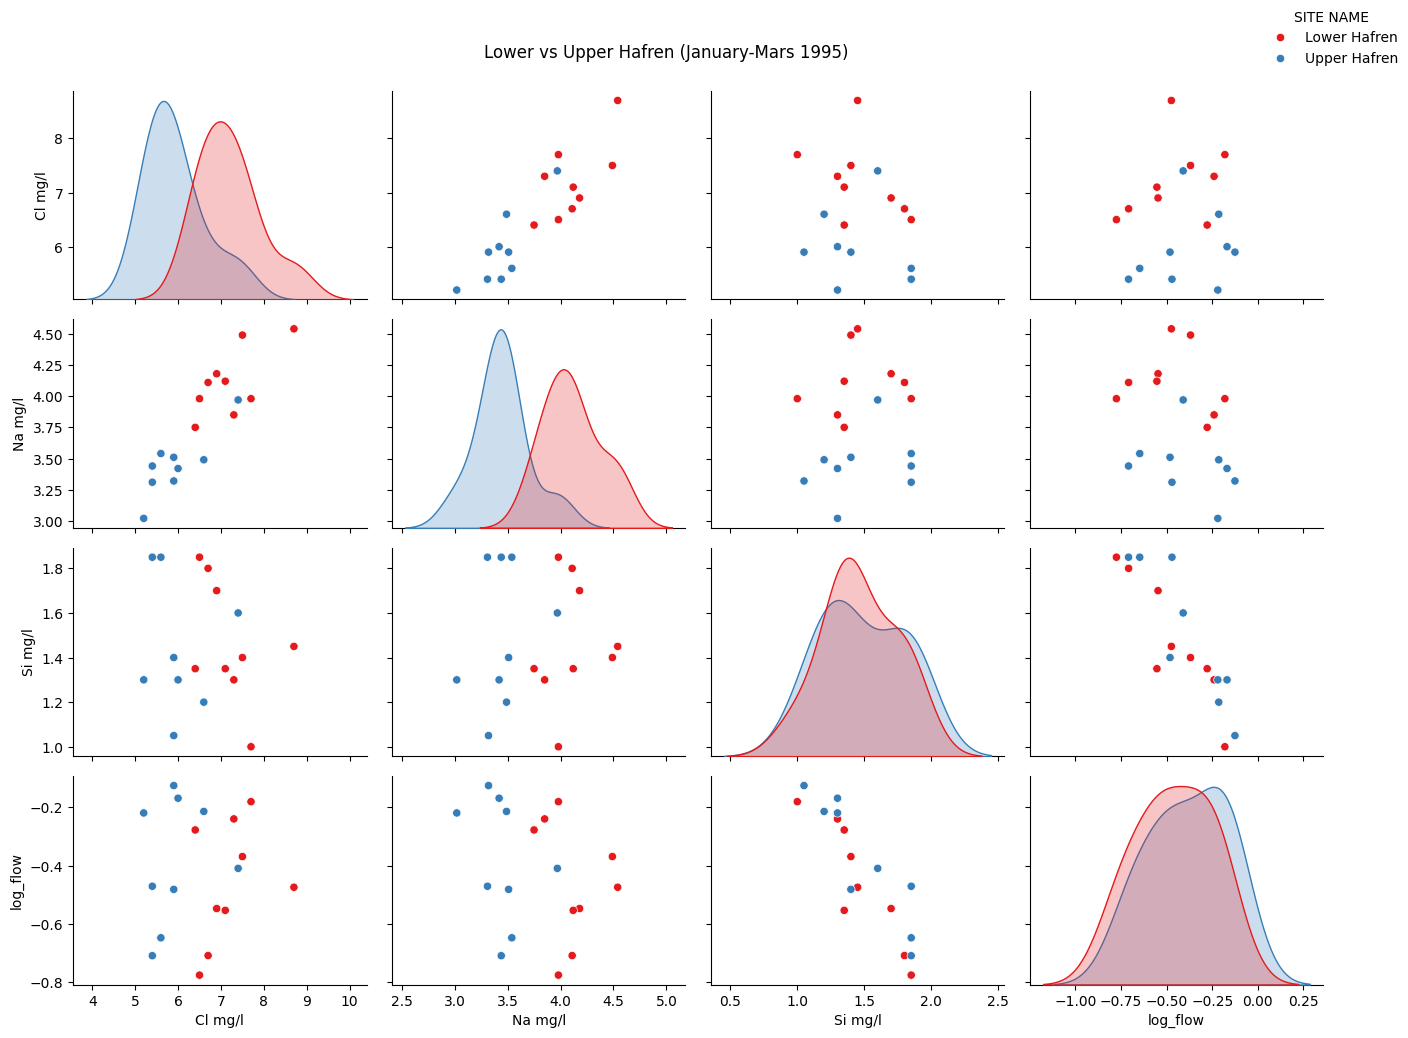

In [74]:
# sample 15070
measurements = [
    "SITE NAME",          # for the location
    "date_time",          # for the time
    "Cl mg/l",            # element of interest
    "Na mg/l",
    "Si mg/l",
    "log_flow",
    ]

q = (
    (df["SITE NAME"].isin(["Lower Hafren", "Upper Hafren"])) &
    (df["date_time"] >= '1995-01-01') &
    (df["date_time"] < '1995-03-01')
)

df1 = df.loc[q, measurements]
print(df1.head())

measurements_to_plot = [col for col in measurements if col not in ["SITE NAME", "date_time"]]

# Créer le pairplot
g = sns.pairplot(
    df1,
    vars=vars_to_plot,
    hue="SITE NAME",
    palette="Set1",
    height=2.5,
    aspect=1.2
)

# Titre
g.fig.suptitle("Lower vs Upper Hafren (January-Mars 1995)", y=1.0)


# Légende
legend = g._legend
legend.set_bbox_to_anchor((1.05, 1))
legend.loc = "upper left"

# Mise en page
plt.tight_layout()
plt.show()


### Exercise #2

We want to visualize different variables in a timeseries. As usual, we want to do this separately for the Upper and Lower Hafren sites.

Again, you are free to select your measurements of interest. Make sure you include at least: "Cl mg/l", "Na mg/l", "Si mg/l", "log_flow"   

To display multiple variables automatically in one plot, you will need to reshape the dataset to make it longer.

To display different timeseries in different *facets* (i.e. different panels), it is convenient to use the `sns.relplot` ([documentation](https://seaborn.pydata.org/generated/seaborn.relplot.html)). With the relplot you can build a grid in the figure and map variables to the rows and columns of such grid. When doing this, it is good to avoid sharing the same y-axis across subplots, because different measurements have different scales. To do so, you can pass the argument `facet_kws={'sharey': False, 'sharex': True}` to the plot function.

Text(0.5, 1.0, 'Time Series: Cl, Na, Si, log_flow (January-Mars 1995)')

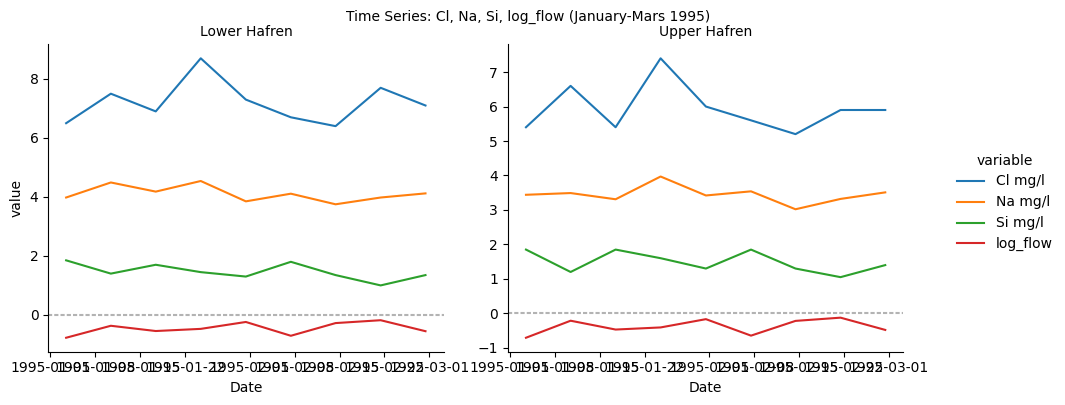

In [76]:
# Reshape the data to make it longer
df1_long = pd.melt(
    df1,
    id_vars = ["SITE NAME","date_time"],
    value_vars = ["Cl mg/l", "Na mg/l", "Si mg/l" ,"log_flow"]
    )

#print(df1_long.shape)
df1_long

# Replot
g = sns.relplot(
    df1_long,
    x="date_time",
    y="value",
    hue="variable",
    col="SITE NAME",
    kind="line",
    height=4,
    aspect=1.2,
    facet_kws={'sharey': False, 'sharex': True}
)

g.map(plt.axhline, y=0, color=".7", dashes=(2, 1), zorder=0)

g.set_xlabels("Date")
g.set_ylabels("value")
g.set_titles(col_template="{col_name}")
g.tight_layout(w_pad=0)

g.fig.suptitle("Time Series: Cl, Na, Si, log_flow (January-Mars 1995)", y=1.0, fontsize=10)

### Exercise #3

We want to explore the presence of seasonal cycles in the measurements. To do so, we want to compute long-term mean monthly values. As in the previous exercises, we want to do this separately for the Upper and Lower Hafren sites.

They key point here is to make the table longer and group the dataset by site, variable and month (need to select or create a `month` variable for this). As in the previous exercise, you can display the results using a `sns.relplot`.

In [77]:

# make it longer
df_monthly_long = pd.melt(
    df_monthly,
    id_vars = ["SITE NAME", "month"],
    value_vars = ["Cl mg/l", "Na mg/l", "Si mg/l", "log_flow"]
)

g = sns.relplot(
    data=df_monthly_long,
    x="month",
    y="value",
    hue="variable",
    col="SITE NAME",
    kind="line",
    marker="o",
    height=4,
    aspect=1.2,
    facet_kws={'sharey': False, 'sharex': True}
)

g.set_xlabels("Month")
g.set_ylabels("Mean Value")
g.set_titles(col_template="{col_name}")

# Afficher les noms des mois au lieu des indices
month_names = {1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
               7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"}
for ax in g.axes.flat:
    ax.set_xticks(list(range(1, 13)))
    ax.set_xticklabels([month_names[m] for m in range(1, 13)])

g.fig.suptitle("Long-Term Mean Monthly Values", y=1.02)
plt.tight_layout()
plt.show()


KeyError: "The following id_vars or value_vars are not present in the DataFrame: ['SITE NAME', 'month']"